In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/xAI_Banking_Paper/data/SBAnational.csv',low_memory=False)
df.head()

,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,...,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv
0,1000014003,ABC HOBBYCRAFT,EVANSVILLE,IN,47711,FIFTH THIRD BANK,OH,451120,28-Feb-97,1997,...,N,Y,NaN,28-Feb-99,"$60,000.00",$0.00,P I F,$0.00,"$60,000.00","$48,000.00"
1,1000024006,LANDMARK BAR & GRILLE (THE),NEW PARIS,IN,46526,1ST SOURCE BANK,IN,722410,28-Feb-97,1997,...,N,Y,NaN,31-May-97,"$40,000.00",$0.00,P I F,$0.00,"$40,000.00","$32,000.00"
2,1000034009,"WHITLOCK DDS, TODD M.",BLOOMINGTON,IN,47401,GRANT COUNTY STATE BANK,IN,621210,28-Feb-97,1997,...,N,N,NaN,31-Dec-97,"$287,000.00",$0.00,P I F,$0.00,"$287,000.00","$215,250.00"
3,1000044001,"BIG BUCKS PAWN & JEWELRY, LLC",BROKEN ARROW,OK,74012,1ST NATL BK & TR CO OF BROKEN,OK,0,28-Feb-97,1997,...,N,Y,NaN,30-Jun-97,"$35,000.00",$0.00,P I F,$0.00,"$35,000.00","$28,000.00"
4,1000054004,"ANASTASIA CONFECTIONS, INC.",ORLANDO,FL,32801,FLORIDA BUS. DEVEL CORP,FL,0,28-Feb-97,1997,...,N,N,NaN,14-May-97,"$229,000.00",$0.00,P I F,$0.00,"$229,000.00","$229,000.00"


In [5]:
import pandas as pd
import numpy as np
import cupy as cp
from fknni import FastKNNImputer
from sklearn.ensemble import IsolationForest

# 1. Load the dataset
file_path = '/content/drive/MyDrive/xAI_Banking_Paper/data/SBAnational.csv'
df = pd.read_csv(file_path, low_memory=False)
print(f"Initial shape: {df.shape}")

# 2. Clean target variable MIS_Status
df = df.dropna(subset=['MIS_Status'])
status_map = {'P I F': 0, 'CHGOFF': 1}
print("before mapping:",df['MIS_Status'].value_counts())
df['MIS_Status'] = df['MIS_Status'].map(status_map)
print("after mapping:",df['MIS_Status'].value_counts())

# 3. Drop columns identified as non-predictive or leading to data leakage
columns_to_drop = [
    'LoanNr_ChkDgt', 'Name', 'ChgOffDate', 'ChgOffPrinGr', # Already identified
    'City', 'State', 'Zip', 'Bank', 'BankState',           # High cardinality/redundant categorical-like
    'ApprovalDate', 'DisbursementDate' , 'ApprovalFY'      # Date columns, not used as numerical and need feature engineering if kept
]
df = df.drop(columns=columns_to_drop, errors='ignore')

# 4. Clean financial columns (currency strings to float)
curr_cols = ['DisbursementGross', 'BalanceGross', 'GrAppv', 'SBA_Appv']
for col in curr_cols:
    df[col] = df[col].replace('[\\$, ]', '', regex=True).astype(float)

# 5. Handle missing values in specific categorical-like columns
df['NewExist'] = df['NewExist'].replace(0, np.nan)
df['RevLineCr'] = df['RevLineCr'].where(df['RevLineCr'].isin(['Y', 'N']), np.nan)
df['LowDoc'] = df['LowDoc'].where(df['LowDoc'].isin(['Y', 'N']), np.nan)

YN_map = {'N': 0, 'Y': 1}
df['RevLineCr'] = df['RevLineCr'].map(YN_map)
df['LowDoc'] = df['LowDoc'].map(YN_map)

# Identify numeric columns for imputation after all drops
numeric_cols = df.select_dtypes(include=[np.number]).columns

# To force fknni to use the GPU (cuML) backend, pass it a CuPy array
X_numeric = df[numeric_cols].values
X_cupy = cp.array(X_numeric)

print("Starting GPU-accelerated KNN Imputation with median strategy...")
imputer = FastKNNImputer(n_neighbors=5, strategy='median')
X_imputed_cupy = imputer.fit_transform(X_cupy)

# Convert back to pandas and update DataFrame
df[numeric_cols] = cp.asnumpy(X_imputed_cupy)

# 6. Filter Outliers using Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)
outliers = iso.fit_predict(df[numeric_cols])
df = df[outliers == 1]

# 7. Save intermediate cleaned dataset
output_path = '/content/processed_v1.csv'
df.to_csv(output_path, index=False)
print(f"Final shape after preprocessing: {df.shape}")
display(df.head())

Initial shape: (899164, 27)
before mapping: MIS_Status
P I F     739609
CHGOFF    157558
Name: count, dtype: int64
after mapping: MIS_Status
0    739609
1    157558
Name: count, dtype: int64
Starting GPU-accelerated KNN Imputation with median strategy...
Final shape after preprocessing: (852308, 16)


,NAICS,ApprovalFY,Term,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,DisbursementGross,BalanceGross,MIS_Status,GrAppv,SBA_Appv
0,451120.0,1997,84.0,4.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0,60000.0,0.0,0.0,60000.0,48000.0
1,722410.0,1997,60.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0,40000.0,0.0,0.0,40000.0,32000.0
2,621210.0,1997,180.0,7.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,287000.0,0.0,0.0,287000.0,215250.0
3,0.0,1997,60.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,35000.0,0.0,0.0,35000.0,28000.0
4,0.0,1997,240.0,14.0,1.0,7.0,7.0,1.0,0.0,0.0,0.0,229000.0,0.0,0.0,229000.0,229000.0


### Inspecting the Processed Data

Let's load the `processed_v1.csv` file and confirm that the numeric missing values have been imputed and understand the final data structure.

In [11]:
import pandas as pd
import numpy as np

# Load the processed CSV file
df_processed = pd.read_csv('/content/processed_v1.csv')

print('Info of the processed DataFrame:')
df_processed.info()

print('\nMissing values in the processed DataFrame:')
print(df_processed.isnull().sum()[df_processed.isnull().sum() > 0])

print('\nFirst 5 rows of the processed DataFrame:')
display(df_processed.head())

/tmp/ipykernel_1068/3331570109.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_processed = pd.read_csv('/content/processed_v1.csv')


Info of the processed DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 852308 entries, 0 to 852307
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   NAICS              852308 non-null  float64
 1   ApprovalFY         852308 non-null  object 
 2   Term               852308 non-null  float64
 3   NoEmp              852308 non-null  float64
 4   NewExist           852308 non-null  float64
 5   CreateJob          852308 non-null  float64
 6   RetainedJob        852308 non-null  float64
 7   FranchiseCode      852308 non-null  float64
 8   UrbanRural         852308 non-null  float64
 9   RevLineCr          852308 non-null  float64
 10  LowDoc             852308 non-null  float64
 11  DisbursementGross  852308 non-null  float64
 12  BalanceGross       852308 non-null  float64
 13  MIS_Status         852308 non-null  float64
 14  GrAppv             852308 non-null  float64
 15  SBA_Appv          

,NAICS,ApprovalFY,Term,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,DisbursementGross,BalanceGross,MIS_Status,GrAppv,SBA_Appv
0,451120.0,1997,84.0,4.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0,60000.0,0.0,0.0,60000.0,48000.0
1,722410.0,1997,60.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0,40000.0,0.0,0.0,40000.0,32000.0
2,621210.0,1997,180.0,7.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,287000.0,0.0,0.0,287000.0,215250.0
3,0.0,1997,60.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,35000.0,0.0,0.0,35000.0,28000.0
4,0.0,1997,240.0,14.0,1.0,7.0,7.0,1.0,0.0,0.0,0.0,229000.0,0.0,0.0,229000.0,229000.0


### Comparing Feature Distributions (Before vs. After Processing)

Now, let's visualize how the distributions of some key numeric features have changed after the imputation and outlier filtering. We'll compare the original numeric values (from `X_numeric`) with the values in the `df_processed` DataFrame.

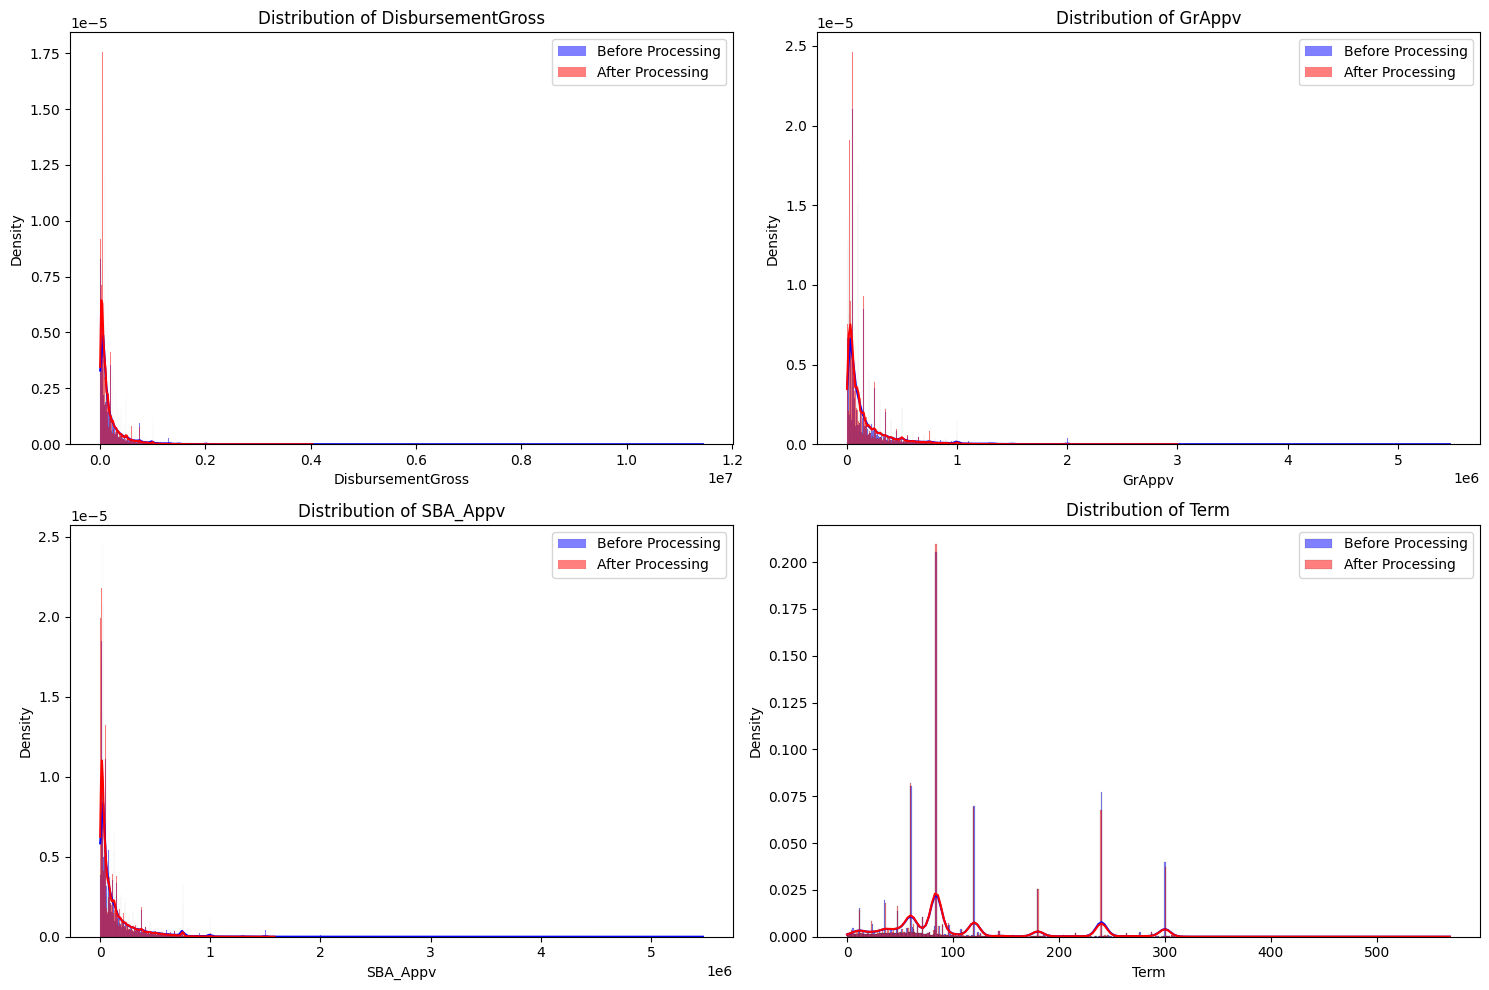

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import cupy as cp

# Get numeric column names from the global state (assuming `numeric_cols` is still available)
# If numeric_cols is not in global state, uncomment and re-run initial preprocessing steps to define it.
# numeric_cols = df.select_dtypes(include=[np.number]).columns # This would need the original df state

# Create a DataFrame for the original numeric data (before imputation and outlier removal)
# X_numeric comes from the kernel state and represents the numeric columns before imputation.
# We need to explicitly convert it to pandas and assign column names.
df_original_numeric = pd.DataFrame(X_numeric, columns=numeric_cols)

# Select a few representative numeric columns for comparison
comparison_cols = ['DisbursementGross', 'GrAppv', 'SBA_Appv', 'Term']

plt.figure(figsize=(15, 10))
for i, col in enumerate(comparison_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df_original_numeric[col], color='blue', label='Before Processing', kde=True, stat='density', alpha=0.5)
    sns.histplot(df_processed[col], color='red', label='After Processing', kde=True, stat='density', alpha=0.5)
    plt.title(f'Distribution of {col}')
    plt.legend()
plt.tight_layout()
plt.show()

The distributions show the impact of both the KNN imputation and the Isolation Forest outlier removal. For example, the tails of the distributions might be trimmed, and some gaps might be filled due to imputation. The `UserWarning: Fallback data (as defined by passed strategy) were used` from `fknni` indicates that some values might have been imputed using a simpler fallback method (e.g., mean/median) rather than KNN for certain edge cases, potentially due to insufficient neighbors or other data characteristics.

It's important to analyze these changes and ensure they align with the expected impact of the preprocessing steps on your data.

In [14]:
import pandas as pd
import numpy as np
import os

# 1. Load the intermediate cleaned dataset
cleaned_path = "/content/processed_v1.csv"
if not os.path.exists(cleaned_path):
    raise FileNotFoundError("Could not find processed_v1.csv in your Colab workspace!")

df = pd.read_csv(cleaned_path)
print(f"Loaded processed_v1.csv successfully. Shape: {df.shape}")

# Define our target column
target_col = 'MIS_Status'
if target_col not in df.columns:
    target_col = [col for col in df.columns if 'default' in col.lower() or 'status' in col.lower() or 'distress' in col.lower()]

y = df[target_col]
X = df.drop(columns=[target_col])

# =====================================================================
# CRITICAL METHODOLOGICAL UPDATE:
# We DO NOT apply StandardScaler here. Scaling must happen WITHIN
# the cross-validation folds during Week 2 training to prevent
# data leakage. We keep the continuous variables in their organic state.
# =====================================================================

# 2. Handle Categorical Columns
# Identify text object columns and low-cardinality numeric codes (like NewExist, UrbanRural, LowDoc, RevLineCr)
categorical_cols = X.select_dtypes(exclude=['number']).columns.tolist()
low_cardinality_numeric = [col for col in X.select_dtypes(include=['number']).columns
                           if X[col].nunique() <= 10]
categorical_cols.extend(low_cardinality_numeric)
categorical_cols = list(set(categorical_cols)) # Remove duplicates

print(f"Categorical features identified for One-Hot Encoding: {categorical_cols}")

# One-hot encode categorical features (safe to do before splitting as the categories are fixed)
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 3. Reconstruct and Save the Cleaned, Unscaled Dataset
processed_df = X_encoded.copy()
processed_df[target_col] = y

# Create output directories
os.makedirs("data/processed", exist_ok=True)
output_path = "data/processed/processed_sme_final.csv"
processed_df.to_csv(output_path, index=False)

print("\n" + "="*50)
print("WEEK 1 PREPROCESSING COMPLETE (LEAK-PROOF & ORGANIC)")
print("="*50)
print(f"Final Preprocessed Dataset Shape: {processed_df.shape}")
print(f"Saved to: {output_path}")
print("\nNatural Prior Class Distribution:")
print(processed_df[target_col].value_counts(normalize=True))
print("StandardScaler postponed to Week 2 model-fitting folds.")
print("="*50)

/tmp/ipykernel_1068/3959338778.py:10: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cleaned_path)


Loaded processed_v1.csv successfully. Shape: (852308, 16)
Categorical features identified for One-Hot Encoding: ['UrbanRural', 'ApprovalFY', 'NewExist', 'LowDoc', 'RevLineCr']

WEEK 1 PREPROCESSING COMPLETE (LEAK-PROOF & ORGANIC)
Final Preprocessed Dataset Shape: (852308, 79)
Saved to: data/processed/processed_sme_final.csv

Natural Prior Class Distribution:
MIS_Status
0.0    0.826789
1.0    0.173211
Name: proportion, dtype: float64
StandardScaler postponed to Week 2 model-fitting folds.
